# Project 8: Forward Volatility from the SOFR Cap Market (Group B15)

**Data**: `project_cap_vol_ts.xlsx`, `cap_curves_2025-06-30.xlsx`, `ref_rates.xlsx`

## Project Statement

Strip forward volatilities from the SOFR cap market over 2022–2025 and test whether the forward vol curve predicts future spot vol—a Fama–Bliss analog for the volatility term structure. Characterize the resulting volatility term premium and analyze how it varies across the hiking, pause, and easing regimes of the Fed's policy cycle.

## Context

### From Flat Vol to Forward Vol

In the cap market, prices are quoted in **flat volatility**—a single implied vol that prices all caplets in a given cap, regardless of their individual maturities. This is a quoting convention, analogous to yield-to-maturity for bonds. Just as bond pricing requires spot rates (not YTM), derivative pricing requires **forward volatilities** that assign each caplet its own vol consistent with its maturity.

Extracting forward vols from flat vols is a **bootstrap** problem: given a sequence of cap prices at maturities $T_1 < T_2 < \ldots$, strip out the incremental caplet prices and invert Black's formula to recover the forward vol at each tenor. Exercise 7.1 walks through this on a single date.

### The Vol Curve as a Forecast

The forward vol curve has a natural interpretation as a forecast of future rate volatility. The $\tau$-year forward caplet vol represents the market's expectation (plus any risk premium) for rate volatility during the quarter ending at $\tau$.

A natural question, then, is whether forward vol is an unbiased predictor of future spot vol. This is the **Fama–Bliss analog for volatility**: just as forward rates predict future spot rates (but with a term premium), forward vols may predict future spot vols—but with a **volatility term premium**.

### Normal vs Black Vol

Bloomberg quotes cap vols in **normal** (Bachelier) terms, reported in basis points. For comparing forward vol across different rate levels and to realized rate volatility, normal vol is the appropriate measure:

$$\sigma_{\text{normal}} \approx \sigma_{\text{Black}} \times f$$

where $f$ is the forward rate. This approximation is exact at-the-money.

### The 2022–2025 Rate Cycle

This project covers a period of extraordinary rate volatility:

| Period | Regime | SOFR Range | Implication |
|--------|--------|------------|-------------|
| Mar 2022 – Jul 2023 | Aggressive hiking | 0.05% → 5.30% | High realized vol, uncertain terminal rate |
| Aug 2023 – Aug 2024 | Pause | ~5.30% | Low realized vol, high implied vol (when does the cut come?) |
| Sep 2024 – Dec 2025 | Easing | 5.30% → ~3.75% | Moderate realized vol, declining implied vol |

These three regimes create a natural laboratory for studying how the volatility term premium behaves under different policy conditions.

## Resources

### Course Materials

- **Discussion 7.1**: Forward Volatility and Caps — flat vs forward vol, stripping mechanics, Black's formula for caplets
- **Exercise 7.1**: Stripping Caps — single-date bootstrap of forward vols from flat vols (the starting point for Q1)
- **Discussion 5.1**: SOFR Swap Curve — discount factor construction needed for cap pricing

### External Reading

- CME Group: [Interest Rate Volatility](https://www.cmegroup.com/education/courses/introduction-to-interest-rate-options.html) — market structure for rate options
- NY Fed: [SOFR](https://www.newyorkfed.org/markets/reference-rates/sofr) — rate calculation methodology
- Federal Reserve: [FOMC Calendars](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm) — policy dates for regime classification

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `project_cap_vol_ts.xlsx` | Cap flat vols (normal, bp) + SOFR swap rates | Daily | 2022–2025 |
| `cap_curves_2025-06-30.xlsx` | Processed rate/vol curves for validation | Single date | 2025-06-30 |
| `ref_rates.xlsx` | Daily SOFR, Fed Funds, T-bill rates | Daily | 2018–2025 |

**Data location**: All files are in the `./data/` directory relative to this notebook.

#### Cap Vol Data Details

The `project_cap_vol_ts.xlsx` file contains two sheets:
- **`cap`**: ATM normal vol quotes for 1Y–10Y SOFR caps (Bloomberg `USCNSQ{1-10} SMKO Curncy`). Vols are in basis points.
- **`sofr`**: SOFR swap rates at monthly/quarterly/annual tenors up to 10Y. Rates are in percent, annually compounded.

The first row of each sheet contains maturity metadata (in years). Subsequent rows are daily observations.

### Additional Data Sources
- **FRED**: Daily SOFR rate for realized vol computation (already in `ref_rates.xlsx`)
- **Bloomberg** (optional): If you have access, you can pull additional cap maturities or OTM strikes via the `VCUB` screen

### AI Use
- **Claude Code**: Combined each of our individual notebooks into a single unified one, as well as gave "rigorous and critical" feedback on our commentary.

## Data Preview

The following code loads the data and creates initial visualizations.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import PchipInterpolator
import statsmodels.api as sm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('./data')

In [40]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest quarter (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

print(f'Cap data: {cap_data.shape[0]} days, maturities: {list(cap_data.columns)}')
print(f'Date range: {cap_data.index.min().date()} to {cap_data.index.max().date()}')
cap_data.tail(3)

Cap data: 989 days, maturities: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Date range: 2022-03-17 to 2025-12-31


maturity,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
date,,,,,,,,,,
2025-12-29,52.2,66.8,73.5,77.3,79.6,81.2,82.1,82.8,83.3,83.7
2025-12-30,50.9,66.1,72.9,76.7,78.9,80.4,81.3,81.9,82.4,82.8
2025-12-31,50.8,65.9,72.9,76.7,78.9,80.4,81.4,82.0,NaN,NaN


In [41]:
# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

print(f'SOFR swap data: {sofr_data.shape[0]} days, {sofr_data.shape[1]} tenors')
sofr_data.tail(3)

SOFR swap data: 1033 days, 21 tenors


maturity,0.25,0.50,0.75,1.00,1.25,1.50,1.75,...,4.50,5.00,6.00,7.00,8.00,9.00,10.00
date,,,,,,,,,,,,,,,
2025-12-29,0.036670,0.035886,0.034989,0.034239,0.033538,0.033140,0.032940,...,0.033746,0.034104,0.034800,0.035506,0.036177,0.036827,0.037457
2025-12-30,0.036567,0.035805,0.034931,0.034190,0.033510,0.033115,0.032919,...,0.033849,0.034214,0.034927,0.035648,0.036330,0.036989,0.037621
2025-12-31,0.036517,0.035796,0.034961,0.034270,0.033631,0.033285,0.033140,...,0.034226,0.034638,0.035355,0.036068,0.036735,0.037388,0.038023


In [42]:
# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100
print(f'SOFR daily: {len(sofr_daily)} observations, {sofr_daily.index.min().date()} to {sofr_daily.index.max().date()}')

SOFR daily: 1935 observations, 2018-04-03 to 2025-12-31


In [43]:
# Load validation curves (single-date, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')

print(f'Validation curves: {curves_validation.shape}')
display(curves_validation.head())

Validation curves: (40, 6)


,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


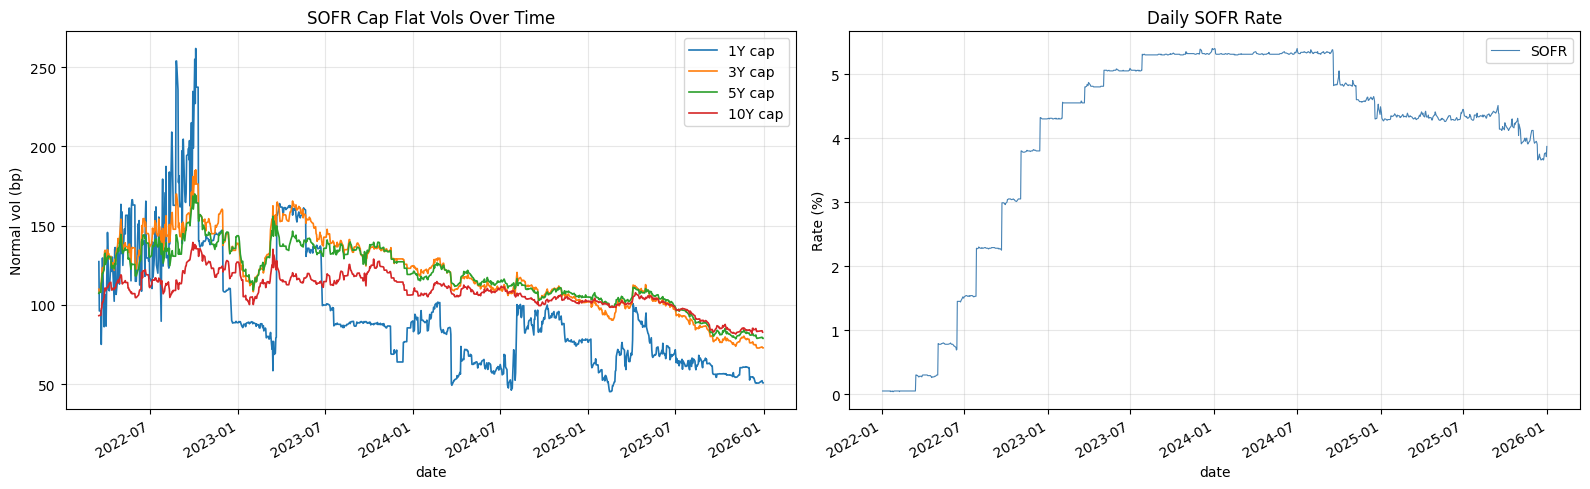

In [44]:
# Figure 1: Cap flat vols over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for mat in [1.0, 3.0, 5.0, 10.0]:
    if mat in cap_data.columns:
        cap_data[mat].dropna().plot(ax=ax, label=f'{int(mat)}Y cap', linewidth=1.2)
ax.set_ylabel('Normal vol (bp)')
ax.set_title('SOFR Cap Flat Vols Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# SOFR rate for context
ax = axes[1]
sofr_rate_pct = sofr_daily.loc['2022':] * 100
sofr_rate_pct.plot(ax=ax, linewidth=0.8, color='steelblue', label='SOFR')
ax.set_ylabel('Rate (%)')
ax.set_title('Daily SOFR Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

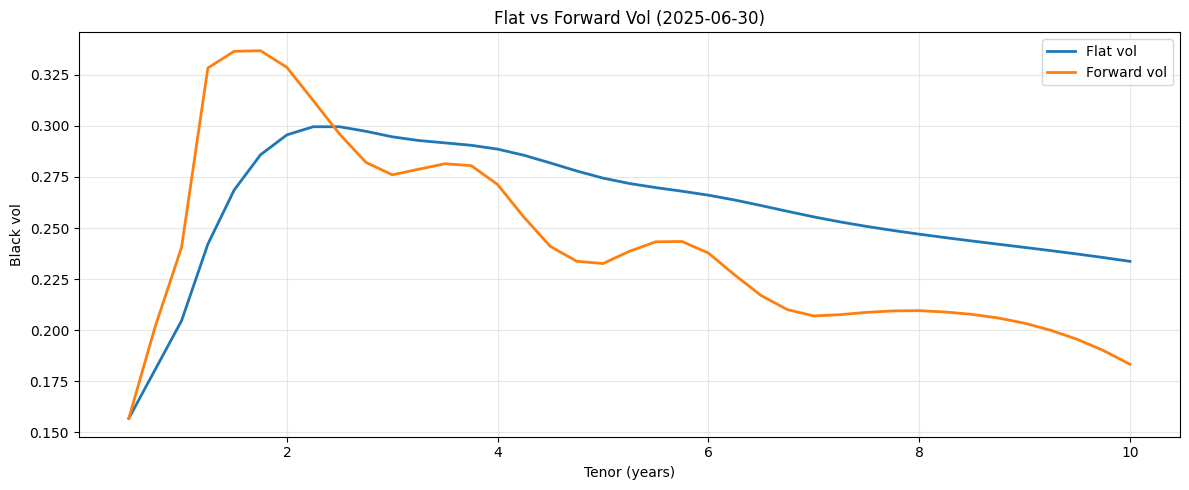

In [45]:
# Figure 2: Flat vs forward vol on the validation date
fig, ax = plt.subplots()
curves_validation['flat vols'].dropna().plot(ax=ax, label='Flat vol', linewidth=2)
curves_validation['fwd vols'].dropna().plot(ax=ax, label='Forward vol', linewidth=2)
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Black vol')
ax.set_title('Flat vs Forward Vol (2025-06-30)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Formulas

Refer to **Discussion 7.1** and **Exercise 7.1** for detailed derivations.

### Black's Formula for a Caplet

$$P_{\text{caplet}} = \frac{100}{4} \cdot Z_\tau \left[ f_\tau \mathcal{N}(d_1) - K \mathcal{N}(d_2) \right]$$

where $d_1 = \frac{\ln(f_\tau/K) + \frac{\sigma^2}{2}(\tau - 0.25)}{\sigma\sqrt{\tau - 0.25}}$ and $d_2 = d_1 - \sigma\sqrt{\tau - 0.25}$.

### Cap Price from Flat Vol

A cap with maturity $T$ and flat vol $\sigma_{\text{flat},T}$:

$$P_{\text{cap}}(T) = \sum_{\tau=0.5}^{T} P_{\text{caplet}}(\tau, \sigma_{\text{flat},T}, K=s_T)$$

where $s_T$ is the ATM swap rate.

### Forward Vol Bootstrap

The caplet price at $\tau$ is:
$$P_{\text{caplet}}(\tau) = P_{\text{cap}}(\tau) - P_{\text{cap}}(\tau - 0.25)$$

Invert Black's formula to find $\sigma_{\text{fwd},\tau}$.

### Normal Vol Conversion (ATM)

$$\sigma_{\text{normal}} = \sigma_{\text{Black}} \times f$$

### Fama–Bliss Analog for Volatility

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

where $h = \tau - \delta$ is the forecast horizon and $\delta$ is the spot caplet tenor.

### Volatility Term Premium

$$\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$$

### Realized Vol

$$\sigma_{\text{realized}, t \to t+k} = \text{std}(\Delta r_{\text{SOFR}}) \times \sqrt{252}$$

computed over daily SOFR rate changes in the window $[t, t+k]$.

## Questions

Address the following questions in your analysis.

### Helper Functions

In [46]:
def get_market_slices(date, cap_data, sofr_data):
    """Extract one-date cap and swap slices."""
    cap_slice = cap_data.loc[date].dropna().astype(float)
    swap_slice = sofr_data.loc[date].dropna().astype(float)
    return cap_slice, swap_slice

In [47]:
def build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid):
    """
    Convert annual cap normal vols (bp) to Black flat vols,
    then PCHIP-interpolate to the quarterly tenor grid.

    PCHIP preserves monotonicity between knots and avoids the
    sawtooth artifacts that linear interpolation introduces in
    the forward vol bootstrap.

    Sub-1Y: a synthetic anchor at 0.5Y (= 1Y flat vol) is added
    so that PCHIP produces a smooth derivative through the 1Y
    boundary, preventing artificial forward vol spikes at 1.25Y.
    """
    normal_vol = cap_slice / 10000.0

    # Swap rates at cap maturities (for normal -> Black conversion)
    approx_atm_rates = (
        swap_slice.reindex(normal_vol.index)
        .interpolate(method="linear", limit_direction="both")
    )

    black_vol = normal_vol / approx_atm_rates

    known_tenors = black_vol.dropna().index.values.astype(float)
    known_vols = black_vol.dropna().values

    # Add synthetic anchor at 0.5Y = 1Y flat vol so PCHIP sees a
    # smooth flat-to-rising transition through the 1Y boundary.
    aug_tenors = np.concatenate([[0.5], known_tenors])
    aug_vols = np.concatenate([[known_vols[0]], known_vols])

    pchip = PchipInterpolator(aug_tenors, aug_vols)

    grid_float = np.array(quarterly_grid, dtype=float)
    flat_vols = pd.Series(dtype=float, index=quarterly_grid)

    for t in grid_float:
        if t >= 0.5:
            flat_vols.loc[t] = float(pchip(t))
        else:
            flat_vols.loc[t] = np.nan

    flat_vols.name = "flat vols"
    flat_vols.loc[0.25] = np.nan
    return flat_vols

In [48]:
def build_quarterly_swap_curve(swap_slice, quarterly_grid):
    """Interpolate swap rates onto the quarterly tenor grid."""
    swap_q = (
        swap_slice.reindex(quarterly_grid)
        .interpolate(method="linear", limit_direction="both")
    )
    swap_q.name = "swap rates"
    return swap_q

In [49]:
def bootstrap_discount_forward_curve(swap_q, delta):
    """
    Vanilla par-swap bootstrap:
      swap rates -> discounts -> spot rates -> forward rates
    """
    tenor_grid = np.array(swap_q.index, dtype=float)

    discounts = pd.Series(index=swap_q.index, dtype=float)

    for j, T in enumerate(tenor_grid, start=1):
        S = swap_q.loc[T]
        if j == 1:
            discounts.loc[T] = 1 / (1 + S * delta)
        else:
            prev_times = tenor_grid[:j-1]
            discounts.loc[T] = (1 - S * delta * discounts.loc[prev_times].sum()) / (1 + S * delta)

    discounts.name = "discounts"

    spot_rates = pd.Series(index=swap_q.index, dtype=float)
    for T in tenor_grid:
        spot_rates.loc[T] = discounts.loc[T] ** (-1 / T) - 1
    spot_rates.name = "spot rates"

    forwards = pd.Series(index=swap_q.index, dtype=float)
    forwards.loc[tenor_grid[0]] = np.nan

    for j in range(1, len(tenor_grid)):
        T_prev = tenor_grid[j-1]
        T = tenor_grid[j]
        forwards.loc[T] = (discounts.loc[T_prev] / discounts.loc[T] - 1) / delta

    forwards.name = "forwards"
    return discounts, spot_rates, forwards

In [50]:
def black_caplet_price(F, K, sigma, tau, DF, delta, notional):
    """Price a single caplet using Black's formula."""
    if pd.isna(F) or pd.isna(K) or pd.isna(sigma) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    if sigma <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    vol_sqrt_t = sigma * np.sqrt(option_expiry)
    if vol_sqrt_t <= 0:
        return notional * delta * DF * max(F - K, 0.0)

    d1 = (np.log(F / K) + 0.5 * sigma**2 * option_expiry) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t

    return notional * delta * DF * (F * norm.cdf(d1) - K * norm.cdf(d2))


def implied_black_caplet_vol(price, F, K, tau, DF, delta, notional):
    """Invert Black's formula to find implied caplet vol via Brent's method."""
    if pd.isna(price) or pd.isna(F) or pd.isna(K) or pd.isna(tau) or pd.isna(DF):
        return np.nan

    option_expiry = tau - delta
    if option_expiry <= 0:
        return np.nan

    intrinsic = notional * delta * DF * max(F - K, 0.0)

    # No time value => no meaningful implied vol
    if price <= intrinsic + 1e-12:
        return np.nan

    def objective(sigma):
        return black_caplet_price(F, K, sigma, tau, DF, delta=delta, notional=notional) - price

    try:
        return brentq(objective, 1e-8, 5.0)
    except ValueError:
        return np.nan

In [51]:
def price_caps_from_flat_vols(flat_vols, swap_q, discounts, forwards, delta, notional):
    """
    Price each T-maturity cap using:
      - flat vol sigma_flat(T)
      - ATM strike K = swap rate at T
      - sum of Black caplets from 0.5 to T
    """
    tenor_grid = np.array(flat_vols.index, dtype=float)
    cap_prices = pd.Series(index=flat_vols.index, dtype=float)

    for T in tenor_grid:
        sigma_flat = flat_vols.loc[T]

        if T < 0.50 or pd.isna(sigma_flat):
            cap_prices.loc[T] = np.nan
            continue

        K = swap_q.loc[T]
        cap_val = 0.0

        caplet_payment_dates = tenor_grid[(tenor_grid >= 0.50) & (tenor_grid <= T)]

        for tau in caplet_payment_dates:
            F = forwards.loc[tau]
            DF = discounts.loc[tau]
            cap_val += black_caplet_price(F=F, K=K, sigma=sigma_flat, tau=tau, DF=DF, delta=delta, notional=notional)

        cap_prices.loc[T] = cap_val

    cap_prices.name = "cap prices"
    return cap_prices

In [52]:
def strip_caplet_prices(cap_prices, delta):
    """
    Strip caplet prices from adjacent cap prices:
      caplet(T) = cap(T) - cap(T - delta)
    Floors at zero to prevent no-arbitrage violations from interpolation noise.
    """
    tenor_grid = np.array(cap_prices.index, dtype=float)
    caplet_prices = pd.Series(index=cap_prices.index, dtype=float)

    for T in tenor_grid:
        if T < 0.50 or pd.isna(cap_prices.loc[T]):
            caplet_prices.loc[T] = np.nan
        elif np.isclose(T, 0.50):
            caplet_prices.loc[T] = cap_prices.loc[T]
        else:
            prev_T = round(T - delta, 10)
            caplet_prices.loc[T] = max(cap_prices.loc[T] - cap_prices.loc[prev_T], 0.0)

    caplet_prices.name = "caplet prices"
    return caplet_prices

In [53]:
def invert_caplet_prices_to_fwd_vols(caplet_prices, swap_q, discounts, forwards, delta, notional):
    """Convert stripped caplet prices to Black forward caplet vols."""
    tenor_grid = np.array(caplet_prices.index, dtype=float)
    fwd_vols = pd.Series(index=caplet_prices.index, dtype=float)

    for tau in tenor_grid:
        if tau < 0.50 or pd.isna(caplet_prices.loc[tau]):
            fwd_vols.loc[tau] = np.nan
            continue

        F = forwards.loc[tau]
        DF = discounts.loc[tau]
        K = swap_q.loc[tau]
        price = caplet_prices.loc[tau]

        fwd_vols.loc[tau] = implied_black_caplet_vol(
            price=price, F=F, K=K, tau=tau, DF=DF, delta=delta, notional=notional
        )

    fwd_vols.name = "fwd vols"
    return fwd_vols

In [54]:
def strip_forward_vol_curve(date, cap_data, sofr_data, quarterly_grid, delta, notional):
    """
    Full one-date pipeline:
      market slices -> flat vols (PCHIP for 1Y+, constant for sub-1Y)
      -> quarterly swap curve -> discounts/spots/forwards
      -> cap prices -> caplet prices -> forward vols
    """
    cap_slice, swap_slice = get_market_slices(date, cap_data, sofr_data)

    flat_vols = build_flat_vol_curve(cap_slice, swap_slice, quarterly_grid=quarterly_grid)
    swap_q = build_quarterly_swap_curve(swap_slice, quarterly_grid=quarterly_grid)

    discounts, spot_rates, forwards = bootstrap_discount_forward_curve(swap_q, delta=delta)

    cap_prices = price_caps_from_flat_vols(
        flat_vols=flat_vols, swap_q=swap_q, discounts=discounts,
        forwards=forwards, delta=delta, notional=notional
    )

    caplet_prices = strip_caplet_prices(cap_prices, delta=delta)

    fwd_vols = invert_caplet_prices_to_fwd_vols(
        caplet_prices=caplet_prices, swap_q=swap_q, discounts=discounts,
        forwards=forwards, delta=delta, notional=notional
    )

    curve = pd.DataFrame({
        "swap rates": swap_q,
        "spot rates": spot_rates,
        "discounts": discounts,
        "forwards": forwards,
        "flat vols": flat_vols,
        "cap prices": cap_prices,
        "caplet prices": caplet_prices,
        "fwd vols": fwd_vols
    })

    return curve

In [55]:
delta = 0.25
notional = 100
quarterly_grid = np.arange(0.25, 10.25, 0.25)
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]

### Question 1: Cap Stripping Mechanics

**Replicate and extend E.7.1 using the provided time-series data.**

a) Select a single date from the time series. Using that date's cap flat vols and SOFR swap curve, build the full processing pipeline:
   - Convert Bloomberg normal vols (bp) to Black vols
   - Interpolate to a quarterly grid
   - Construct discount and forward curves
   - Bootstrap forward vols from flat vols

   Validate your pipeline against the processed `cap_curves_2025-06-30.xlsx` file.

In [56]:
Q1a_date = pd.Timestamp("2025-06-30")
curve_q1 = strip_forward_vol_curve(
    Q1a_date, cap_data, sofr_data,
    quarterly_grid=quarterly_grid, delta=delta, notional=notional
)
display(curve_q1.head(12))

,swap rates,spot rates,discounts,forwards,flat vols,cap prices,caplet prices,fwd vols
0.25,0.043019,0.043718,0.989360,NaN,NaN,NaN,NaN,NaN
0.50,0.041467,0.042107,0.979589,0.039899,0.181032,0.019975,0.019975,0.181032
0.75,0.039991,0.040574,0.970611,0.036997,0.181032,0.054069,0.034094,0.243169
1.00,0.038667,0.039197,0.962282,0.034625,0.181032,0.100740,0.046671,0.285872
1.25,0.037205,0.037672,0.954827,0.031229,0.191924,0.171233,0.070493,0.401137
1.50,0.036121,0.036544,0.947586,0.030565,0.216813,0.268695,0.097461,0.443854
1.75,0.035409,0.035804,0.940296,0.031013,0.244022,0.389751,0.121056,0.445716
2.00,0.034903,0.035279,0.933008,0.031246,0.261869,0.518827,0.129076,0.419092
2.25,0.034435,0.034792,0.925935,0.030555,0.270463,0.645063,0.126236,0.399998
2.50,0.034177,0.034527,0.918639,0.031766,0.277519,0.782307,0.137244,0.365381


In [57]:
# Validate against provided curves
q1_compare = curve_q1[["swap rates", "spot rates", "discounts", "forwards", "flat vols", "fwd vols"]].copy()
q1_compare.index.name = "tenor"

common_index = q1_compare.index.intersection(curves_validation.index)
common_cols = q1_compare.columns.intersection(curves_validation.columns)

validation_compare = curves_validation.loc[common_index, common_cols].copy()
model_compare = q1_compare.loc[common_index, common_cols].copy()

abs_diff = model_compare - validation_compare
rel_diff = abs_diff / validation_compare

validation_summary = pd.DataFrame({
    "mean_abs_error": abs_diff.abs().mean(),
    "max_abs_error": abs_diff.abs().max(),
    "rmse": np.sqrt((abs_diff**2).mean()),
    "mean_rel_error": rel_diff.abs().mean(),
    "max_rel_error": rel_diff.abs().max()
}).sort_index()

display(validation_summary)

,mean_abs_error,max_abs_error,rmse,mean_rel_error,max_rel_error
discounts,0.001864,0.003501,0.002104,0.002364,0.005042
flat vols,0.022683,0.051829,0.025907,0.089948,0.207343
forwards,0.000506,0.000670,0.000518,0.013718,0.015995
fwd vols,0.026314,0.108906,0.040736,0.095144,0.323347
spot rates,0.000954,0.001365,0.000961,0.026962,0.032224
swap rates,0.000469,0.000666,0.000472,0.013270,0.015721


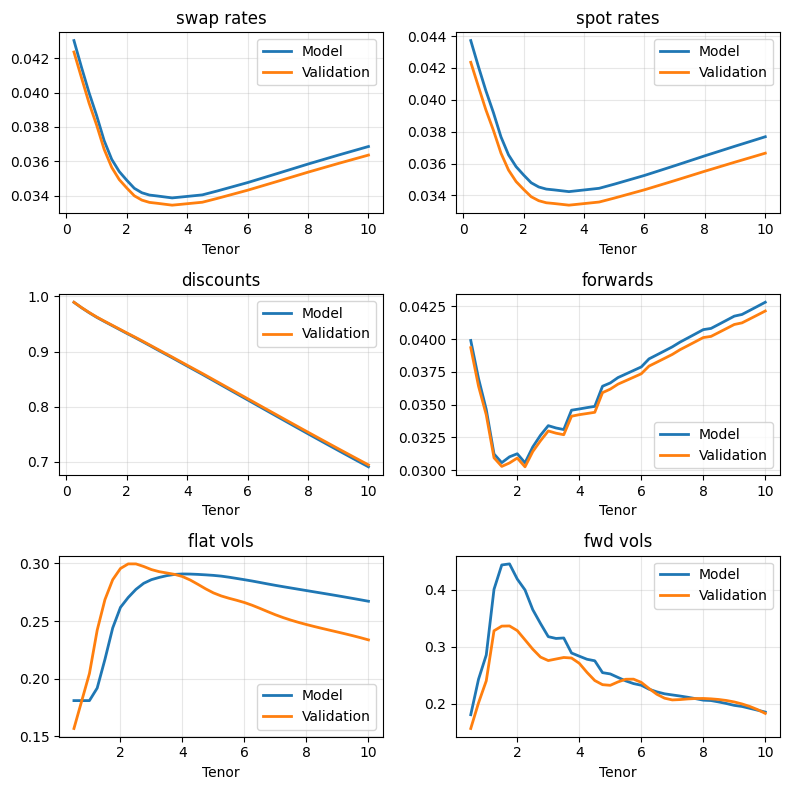

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, col in zip(axes, common_cols):
    model_compare[col].dropna().plot(ax=ax, linewidth=2, label="Model")
    validation_compare[col].dropna().plot(ax=ax, linewidth=2, label="Validation")
    ax.set_title(col)
    ax.set_xlabel("Tenor")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

b) Plot the flat vol and forward vol term structures side by side. The forward vol curve is typically **humped**: near-term vol reflects current policy uncertainty, while long-term vol reverts to a mean. Describe the shape you observe and explain why it looks that way given where the Fed was in its policy cycle on your chosen date.

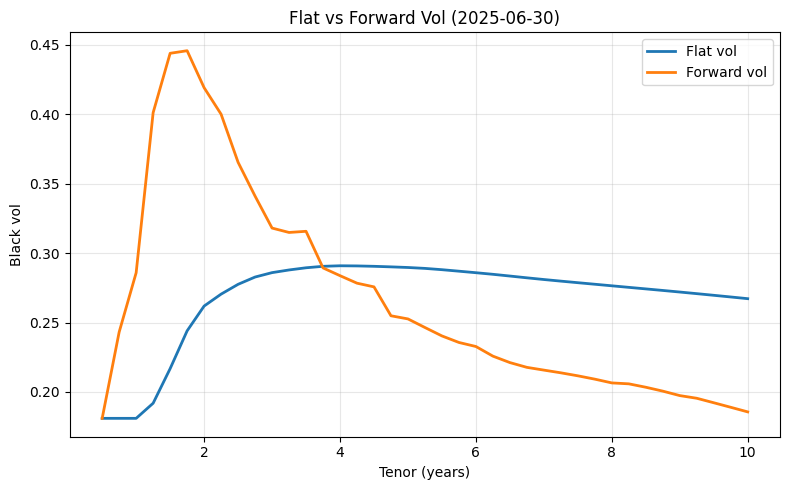

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))

curve_q1["flat vols"].dropna().plot(ax=ax, linewidth=2, label="Flat vol")
curve_q1["fwd vols"].dropna().plot(ax=ax, linewidth=2, label="Forward vol")

ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Black vol")
ax.set_title(f"Flat vs Forward Vol ({Q1a_date.date()})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On 2025-06-30, SOFR sat near ~4.25% after three 25 bp cuts from the 5.30% peak. The forward vol curve displays the characteristic hump: it rises sharply from the 0.75Y region, peaks around 1.5–2Y (~0.45 Black vol), then declines steadily toward a long-run level of ~0.20 beyond 7Y. This shape reflects near-term policy uncertainty while long-dated vols revert to a stable mean as policy uncertainty washes out over longer horizons.

Since there are no cap maturities that exist below 1Y, the bootstrap has limited information about the sub-1Y vol surface. We mitigate this with a synthetic 0.5Y PCHIP anchor (set equal to the 1Y flat vol), which smooths the derivative through the 1Y boundary (although a residual spike remains).

The flat vol curve lies below the forward vol curve at short tenors and above it at long tenors, consistent with its role as a weighted average across all constituent caplets and thus it smooths the hump. The crossover point (roughly around 3–4Y) marks where the marginal caplet vol transitions from above-average to below-average.

c) Repeat Q1b on 3–4 dates spanning the rate cycle (e.g., mid-2022, mid-2023, mid-2024, mid-2025). How does the shape of the forward vol curve change across regimes?

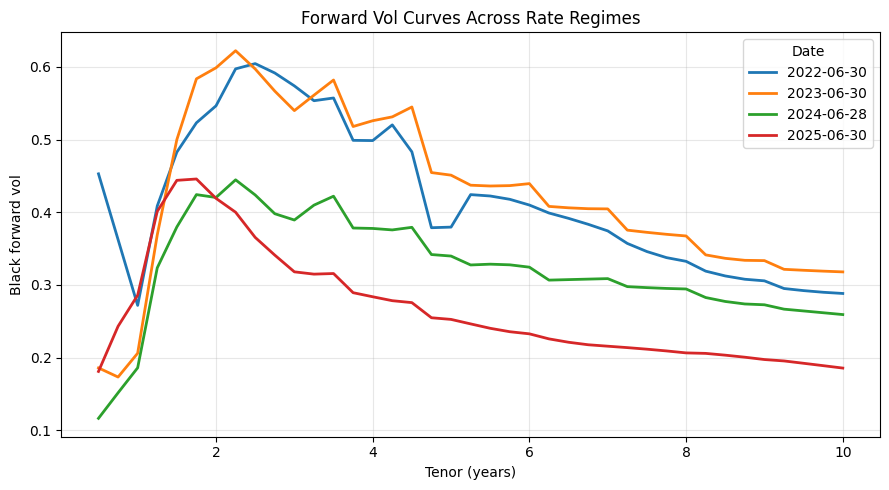

In [60]:
q1c_dates = [
    pd.Timestamp("2022-06-30"),  # Aggressive hiking cycle
    pd.Timestamp("2023-06-30"),  # Late hiking / near peak
    pd.Timestamp("2024-06-28"),  # Pause
    pd.Timestamp("2025-06-30"),  # Easing
]

q1c_curves = {}
for d in q1c_dates:
    q1c_curves[d] = strip_forward_vol_curve(
        d, cap_data=cap_data, sofr_data=sofr_data,
        quarterly_grid=quarterly_grid, delta=delta, notional=notional
    )

fig, ax = plt.subplots(figsize=(9, 5))
for d, curve in q1c_curves.items():
    curve["fwd vols"].dropna().plot(ax=ax, linewidth=2, label=str(d.date()))
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Black forward vol")
ax.set_title("Forward Vol Curves Across Rate Regimes")
ax.legend(title="Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

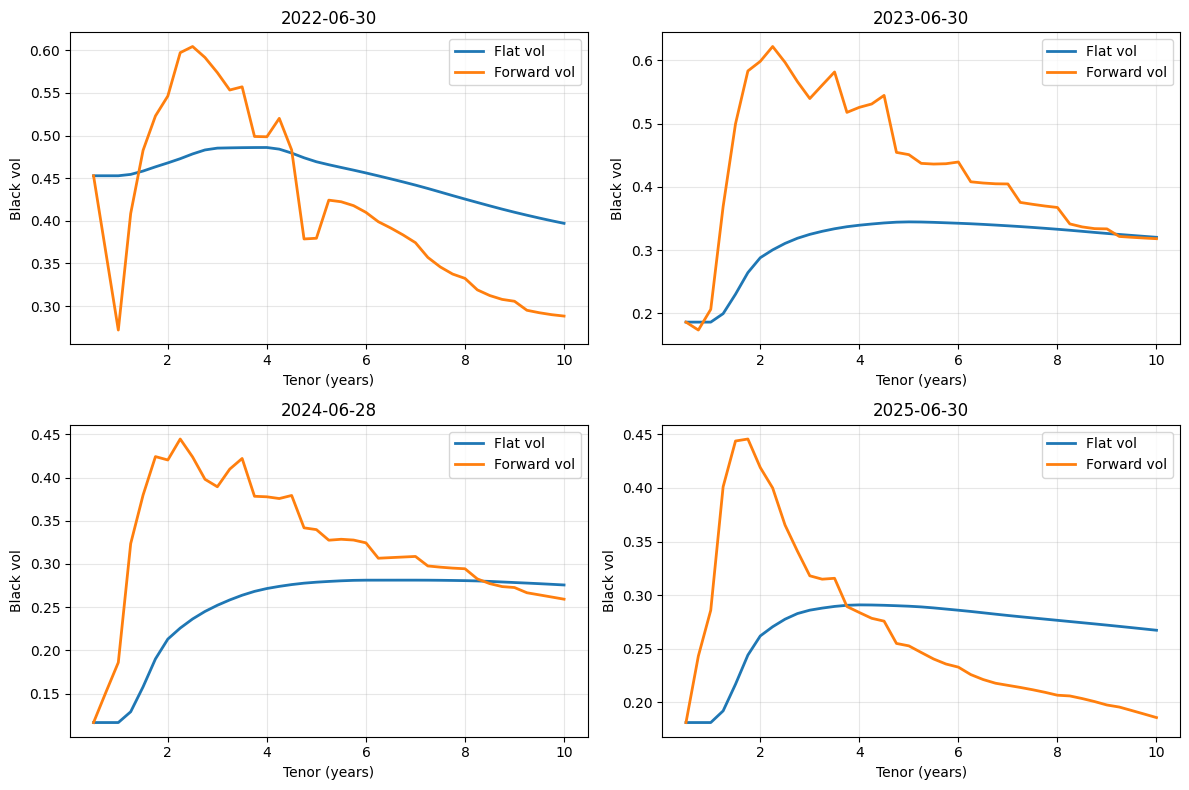

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, d in zip(axes, q1c_dates):
    curve = q1c_curves[d]
    curve["flat vols"].dropna().plot(ax=ax, linewidth=2, label="Flat vol")
    curve["fwd vols"].dropna().plot(ax=ax, linewidth=2, label="Forward vol")
    ax.set_title(str(d.date()))
    ax.set_xlabel("Tenor (years)")
    ax.set_ylabel("Black vol")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

**Q1c — Forward vol curve shape across regimes**

- **2022-06-30 (aggressive hiking):** SOFR had risen from ~0.05% to ~1.5–2% via 50–75 bp hikes. The forward vol curve is elevated in the 1–3Y range and its general level is notably higher than all three of the other forward vol curves, reflecting both large realized rate moves and wide uncertainty about the terminal rate (which was being revised upward from meeting to meeting).

- **2023-06-30 (near peak):** SOFR near ~5.0–5.3% after 500+ bp of cumulative tightening, with the Fed switching to 25 bp increments. The curve remains elevated. In fact, this time its completely above the flat vol curve across all tenors. Compared to the previous date we examined, the hump shifted slightly outward, which indicates that the market was pricing "higher for longer" uncertainty about when cuts would begin, concentrating implied vol in the 1–3Y window yet still distributing vol farther out into longer-dated tenors due to this prevalent uncertainty

- **2024-06-28 (pause):** SOFR held steady at ~5.30% for many months. Realized vol was near zero (since no rate changes), yet implied vol remained elevated as the market was still pricing the timing of the first cut. The curve's shape nearly idential to that of 2023-06-30, except that the overall level is lower. The market was still pricing uncertainty, but the lack of any rate changes causes the overall level of volatility to decrease uniformly among the tenors

- **2025-06-30 (easing):** SOFR had fallen to ~4.25% via several 25 bp cuts. The overall level drops significantly relative to 2022–2023: smaller, more predictable moves compress both the hump and the long end. The forward vol curve concentrates between 1-2Y, reflecting residual uncertainty about the pace and endpoint of easing. Nonetheless, with less mass out towards later tenors, this is indicative of the market viewing the long-term future as relatively well-anchored; the range of plausible rate paths has narrowed, so the insurance value of longer-dated caplets compresses accordingly.

**In sum:** the forward vol curve tracks the Fed's policy regime actions and market expectations. Its most elevated and humped during aggressive hiking with uncertain terminal rates in the short-term, still elevated but less so during the pause, and compressed during the easing phase as move sizes shrink and the range of possible outcomes narrows.

### Question 2: Forward Vol Time Series

**Build a panel of forward vols by stripping the cap curve on each date in the time series.**

a) Process each weekly date in the sample (resample the daily data to weekly frequency). For each date, extract forward caplet vols at key tenors: 0.5Y, 1Y, 2Y, 3Y, 5Y. Store these in a panel indexed by date and tenor.

In [62]:
key_tenors = [0.5, 1.0, 2.0, 3.0, 5.0]
cap_weekly = cap_data.resample("W-FRI").last()
sofr_weekly = sofr_data.resample("W-FRI").last()

weekly_dates = cap_weekly.index.intersection(sofr_weekly.index)

panel_rows = []

for d in weekly_dates:
    cap_row = cap_weekly.loc[d].dropna()
    swap_row = sofr_weekly.loc[d].dropna()

    if cap_row.empty or swap_row.empty:
        continue

    curve = strip_forward_vol_curve(
        d, cap_data=cap_weekly, sofr_data=sofr_weekly,
        quarterly_grid=quarterly_grid, delta=delta, notional=notional
    )

    for tenor in key_tenors:
        panel_rows.append({
            "date": d,
            "tenor": tenor,
            "fwd_vol": curve.loc[tenor, "fwd vols"]
        })

fwd_panel = (
    pd.DataFrame(panel_rows)
    .dropna()
    .sort_values(["date", "tenor"])
    .reset_index(drop=True)
)

fwd_panel_wide = fwd_panel.pivot(index="date", columns="tenor", values="fwd_vol")

print(f"Panel: {fwd_panel.shape[0]} obs, {fwd_panel_wide.shape[0]} weeks, {fwd_panel_wide.shape[1]} tenors")
display(fwd_panel_wide.head())

Panel: 984 obs, 199 weeks, 5 tenors


tenor,0.5,1.0,2.0,3.0,5.0
date,,,,,
2022-03-18,0.702446,NaN,0.224344,0.501641,0.584653
2022-03-25,0.773270,NaN,0.192217,0.460948,0.507270
2022-04-01,0.488851,NaN,0.352209,0.511123,0.660331
2022-04-08,0.584572,NaN,0.278422,0.462709,0.546155
2022-04-15,0.656684,NaN,0.256258,0.443504,0.484442


b) Plot the forward vol time series at each tenor. Describe the dynamics:
   - Which tenors are most volatile?
   - How did forward vol evolve through the hiking cycle (2022–23), the pause (2023–24), and the easing (2024–25)?

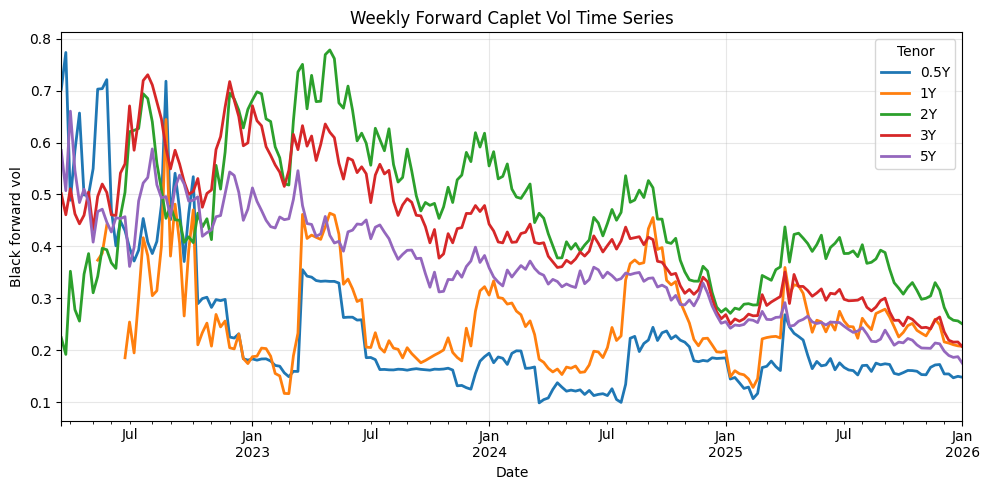

In [63]:
fig, ax = plt.subplots(figsize=(10, 5))

for tenor in fwd_panel_wide.columns:
    fwd_panel_wide[tenor].plot(ax=ax, linewidth=2, label=f"{tenor:g}Y")

ax.set_xlabel("Date")
ax.set_ylabel("Black forward vol")
ax.set_title("Weekly Forward Caplet Vol Time Series")
ax.legend(title="Tenor")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tenor
0.5    0.137557
2.0    0.130881
3.0    0.128691
5.0    0.100710
1.0    0.087160
dtype: float64

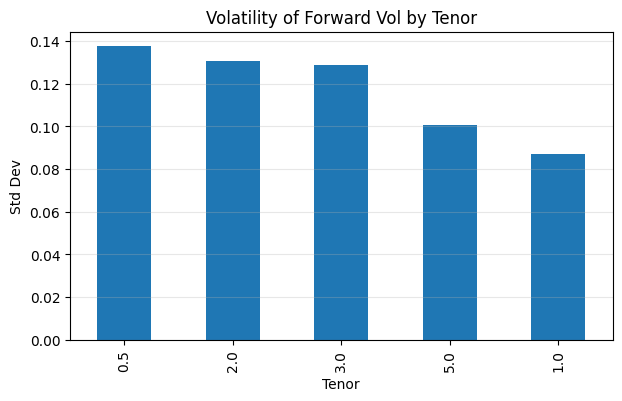

In [64]:
tenor_volatility = fwd_panel_wide.std().sort_values(ascending=False)
display(tenor_volatility)

tenor_volatility.plot(kind="bar", figsize=(7, 4), title="Volatility of Forward Vol by Tenor")
plt.ylabel("Std Dev")
plt.xlabel("Tenor")
plt.grid(axis="y", alpha=0.3)
plt.show()

**Which tenors are most volatile?** The 0.5Y forward vol has the highest week-to-week standard deviation (0.138), as it is the most sensitive to each FOMC decision and incoming data. Medium tenors (2Y: 0.131, 3Y: 0.129) follow closely—these capture "when will the Fed pivot?" uncertainty. The 5Y tenor (0.101) is more anchored by long-run expectations. Perhaps surprisingly, the **1Y tenor is the least volatile** (std = 0.087), likely because the 1Y caplet sits at the boundary of our data (the shortest observed cap maturity) and its forward vol is heavily determined by the 1Y flat vol itself, limiting its variability relative to tenors that are bootstrapped from differences between adjacent caps.

**Dynamics across regimes:**
- **Hiking (2022–23):** Forward vol rises sharply across all tenors. The 0.5Y shows large spikes exceeding 0.70 coinciding with outsized 50–75 bp hikes, while 2–3Y tenors climb as terminal-rate uncertainty intensifies. The 5Y tenor also rises but remains the lowest in level throughout.
- **Pause (2023–24):** Levels stay elevated but become choppier. Realized rate vol drops (no hikes), yet implied vol remains high as the market prices the timing of the first cut. The 0.5Y vol declines from its hiking-era peaks while medium tenors persist at elevated levels.
- **Easing (2024–25):** Forward vol trends downward across all tenors. The predictability of 25 bp cuts compresses both the level and the dispersion across tenors, with all series converging toward the 0.10–0.20 range by late 2025.

c) Report summary statistics (mean, std, min, max) for the forward vol panel. Be sure to discuss whether you are working in Black or normal vol units and why that choice matters for cross-tenor comparisons.

,mean,std,min,max
tenor,,,,
0.5,0.235264,0.137557,0.098893,0.773270
1.0,0.259077,0.087160,0.116681,0.644309
2.0,0.464422,0.130881,0.192217,0.778092
3.0,0.429836,0.128691,0.207054,0.730380
5.0,0.359391,0.100710,0.174827,0.660331


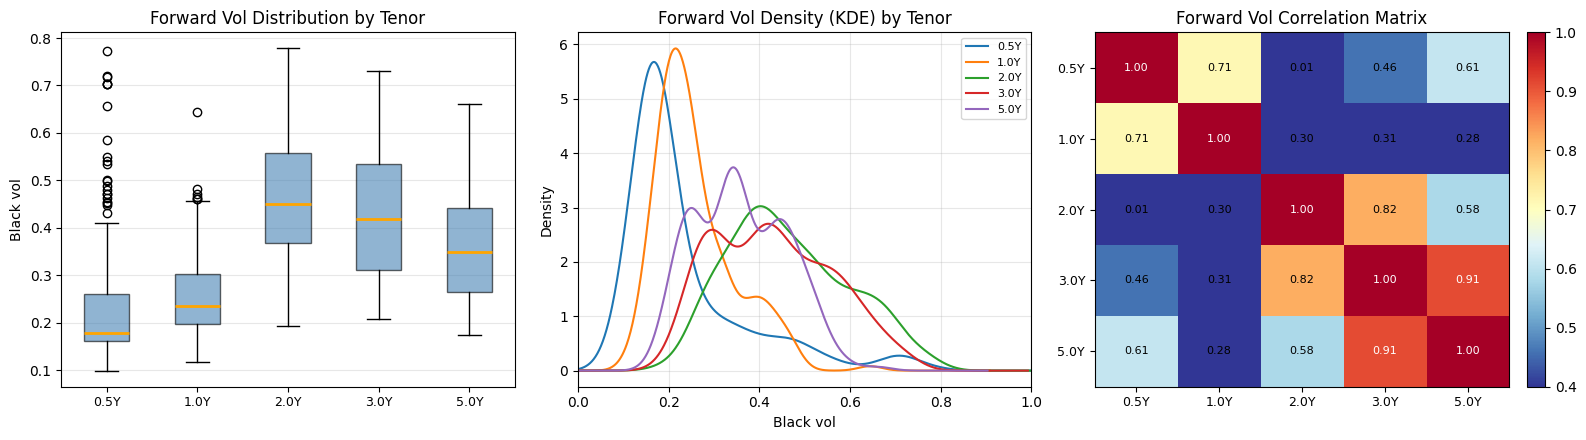

In [65]:
summary_stats = fwd_panel_wide.agg(["mean", "std", "min", "max"]).T
display(summary_stats)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Boxplots by tenor
ax = axes[0]
bp = ax.boxplot(
    [fwd_panel_wide[t].dropna().values for t in fwd_panel_wide.columns],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="orange", linewidth=2),
)
ax.set_xticklabels([f"{t}Y" for t in fwd_panel_wide.columns], fontsize=9)
ax.set_ylabel("Black vol")
ax.set_title("Forward Vol Distribution by Tenor")
ax.grid(axis="y", alpha=0.3)

# 2) KDE overlay
ax = axes[1]
for tenor in fwd_panel_wide.columns:
    series = fwd_panel_wide[tenor].dropna()
    series.plot.kde(ax=ax, label=f"{tenor}Y", linewidth=1.5, bw_method=0.3)
ax.set_xlabel("Black vol")
ax.set_ylabel("Density")
ax.set_title("Forward Vol Density (KDE) by Tenor")
ax.legend(fontsize=8)
ax.set_xlim(0, 1.0)
ax.grid(alpha=0.3)

# 3) Correlation heatmap
ax = axes[2]
corr = fwd_panel_wide.corr()
im = ax.imshow(corr.values, cmap="RdYlBu_r", vmin=0.4, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels([f"{t}Y" for t in corr.columns], fontsize=9)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels([f"{t}Y" for t in corr.index], fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if corr.iloc[i, j] > 0.85 else "black")
ax.set_title("Forward Vol Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

These statistics are in **Black vol** (decimal), the native output of the stripping pipeline. Black vol measures the volatility of the *log* of the forward rate ($\sigma_B$), while normal vol measures the volatility of the *level* ($\sigma_N = \sigma_B \times f$, in bp).

The distinction matters for cross-tenor comparison: a Black vol of 0.30 at a tenor with a 4% forward rate implies 120 bp of normal vol, while the same Black vol at a 3% forward rate implies only 90 bp. Comparing the "amount of rate volatility the market is pricing" across tenors thus requires normal vol. The Q3 regressions and VTP calculations below use normal vol for this reason.

**Boxplots:** The 2Y and 3Y tenors have the widest interquartile ranges, reflecting persistent dispersion across regimes. By contrast, the 0.5Y and 1Y boxes are compact — most observations cluster at low vol levels — but 0.5Y has the most extreme outliers (reaching ~0.77), driven by hiking-era spikes when near-term policy uncertainty was highest. The 1Y tenor's box is the most compact of all, consistent with its low std from Q2b. The gap between 0.5Y's tight IQR and its extreme outliers underscores the regime-driven nature of short-tenor vol: it spends most of its time at low levels but experiences violent episodic spikes.

**KDE:** The density plots confirm this asymmetry. The 0.5Y distribution is sharply peaked near 0.15 with a long right tail. Its nearly bimodal, reflecting the stark difference between easing-era and hiking-era observations. The 2Y and 3Y tenors have flatter, wider distributions centered around 0.40–0.45. This non-normality is a direct consequence of the regime shifts in our sample: hiking-era and easing-era observations form distinct clusters rather than a single bell curve, which means the mean and std alone do not adequately characterize these distributions.

**Correlation:** Adjacent tenors are highly correlated (2Y–3Y = 0.87, 3Y–5Y = 0.91), while 0.5Y is notably decorrelated from the longer tenors (0.5Y–2Y = 0.13, 0.5Y–3Y = 0.46). The 1Y tenor also shows low correlation with the long end (1Y–2Y = 0.36, 1Y-3Y = 0.31). This suggests that a multi-tenor carry strategy from Q6 could benefit from diversifying across the curve. Particularly, by combining a short-tenor position (0.5–1Y) with a long-tenor position (2–3Y), we could capture largely independent sources of vol variation.

### Question 3: Predictive Power of the Forward Vol Curve

**Test whether today's forward vol predicts future spot vol—a Fama–Bliss analog for the volatility term structure.**

*Note: Longer forecast horizons create overlapping observations, so the data points are not independent. Keep this in mind when interpreting $R^2$.*

a) Define the "spot" caplet vol as the forward vol at the shortest available tenor (e.g., 0.5Y). For each forward horizon $\tau$ in your panel, identify the appropriate prediction horizon $h = \tau - \delta$ (where $\delta$ is the spot tenor). Run the predictive regression:

$$\sigma_{\text{spot}}(t{+}h, \delta) = \alpha + \beta \cdot \sigma_{\text{fwd}}(t, \tau) + \varepsilon_t$$

for several forward horizons ($\tau$ = 1Y, 1.5Y, 2Y, 3Y). Use normal vol throughout ($\sigma_N = \sigma_B \times f$).

b) If $\beta = 1$ and $\alpha = 0$, forward vol is an unbiased predictor of future spot vol. Report $\beta$ and $R^2$ for each horizon. Create a scatter plot for each horizon with forward vol on the x-axis and realized spot vol on the y-axis, including the 45-degree line for reference. Interpret the results.

In [76]:
# Build separate Q3 panel with tenors including 1.5Y, in normal vol
spot_tenor = 0.5
q3_tenors = [0.5, 1.0, 1.5, 2.0, 3.0]
tau_horizons = [1.0, 1.5, 2.0, 3.0]

q3_rows = []
for d in weekly_dates:
    cap_row = cap_weekly.loc[d].dropna()
    swap_row = sofr_weekly.loc[d].dropna()
    if cap_row.empty or swap_row.empty:
        continue

    curve = strip_forward_vol_curve(
        d, cap_data=cap_weekly, sofr_data=sofr_weekly,
        quarterly_grid=quarterly_grid, delta=delta, notional=notional
    )

    for tenor in q3_tenors:
        if tenor not in curve.index:
            continue
        fwd_vol_b = curve.loc[tenor, "fwd vols"]
        fwd_rate = curve.loc[tenor, "forwards"]
        if pd.isna(fwd_vol_b) or pd.isna(fwd_rate) or fwd_rate <= 0:
            continue
        q3_rows.append({
            "date": d, "tenor": tenor,
            "fwd_vol_black": fwd_vol_b, "forward_rate": fwd_rate
        })

q3_df = pd.DataFrame(q3_rows)
q3_df["normal_vol"] = q3_df["fwd_vol_black"] * q3_df["forward_rate"]

# Wide panel: index=date, columns=tenor, values=normal_vol
nv_wide = q3_df.pivot(index="date", columns="tenor", values="normal_vol").sort_index()
print(f"Normal vol panel: {nv_wide.shape[0]} weeks x {nv_wide.shape[1]} tenors")
display(nv_wide.tail())

Normal vol panel: 199 weeks x 5 tenors


tenor,0.5,1.0,1.5,2.0,3.0
date,,,,,
2025-12-05,0.005584,0.007140,0.009096,0.009181,0.008044
2025-12-12,0.005522,0.007003,0.008646,0.008706,0.007674
2025-12-19,0.005180,0.006781,0.008354,0.008412,0.007485
2025-12-26,0.005271,0.006736,0.008277,0.008403,0.007514
2026-01-02,0.005198,0.006677,0.008129,0.008260,0.007296


In [67]:
# Predictive regressions with Newey-West HAC standard errors
results = []
models = {}
regression_data = {}

for tau in tau_horizons:
    h_years = tau - spot_tenor
    h_weeks = int(round(h_years * 52))

    df_tau = pd.DataFrame({
        "x_fwd": nv_wide[tau],
        "y_spot_future": nv_wide[spot_tenor].shift(-h_weeks)
    }).dropna()

    X = sm.add_constant(df_tau["x_fwd"])
    y = df_tau["y_spot_future"]

    # Newey-West HAC to account for overlapping observations
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': h_weeks})

    models[tau] = model
    regression_data[tau] = df_tau

    results.append({
        "tau": tau,
        "h (years)": h_years,
        "h (weeks)": h_weeks,
        "n_obs": int(model.nobs),
        "alpha": model.params["const"],
        "beta": model.params["x_fwd"],
        "t_beta (HAC)": model.tvalues["x_fwd"],
        "p_beta (HAC)": model.pvalues["x_fwd"],
        "R2": model.rsquared
    })

q3_results = pd.DataFrame(results)
display(q3_results)

,tau,h (years),h (weeks),n_obs,alpha,beta,t_beta (HAC),p_beta (HAC),R2
0,1.0,0.5,26,162,0.006740,0.156874,1.540196,0.123513,0.033017
1,1.5,1.0,52,141,0.012681,-0.267704,-1.155779,0.247771,0.166566
2,2.0,1.5,78,121,0.008485,-0.059099,-0.965782,0.334153,0.022222
3,3.0,2.5,130,69,0.011339,-0.253880,-3.568294,0.000359,0.167691


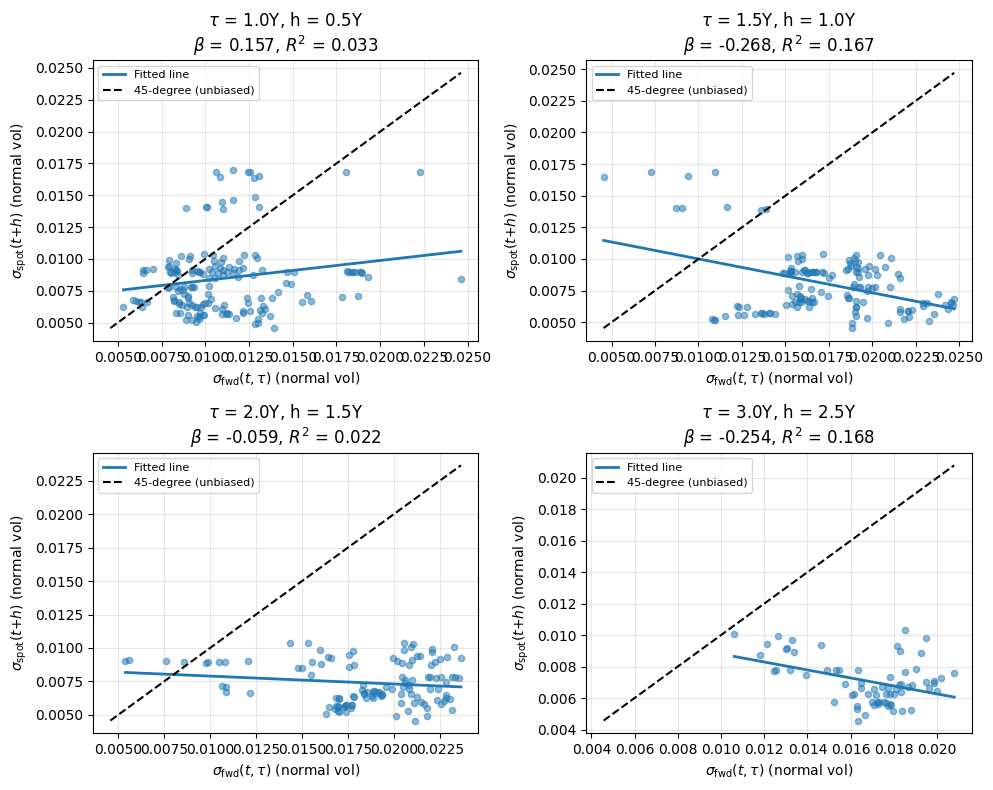

In [68]:
# Scatter plots: forward vol (x) vs realized future spot vol (y)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, tau in zip(axes, tau_horizons):
    df_tau = regression_data[tau]
    model = models[tau]

    x = df_tau["x_fwd"]
    y = df_tau["y_spot_future"]

    ax.scatter(x, y, alpha=0.5, s=20)

    # Fitted line
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_fit = model.params["const"] + model.params["x_fwd"] * x_grid
    ax.plot(x_grid, y_fit, linewidth=2, label="Fitted line")

    # 45-degree line (unbiased benchmark)
    line_min = min(x.min(), y.min())
    line_max = max(x.max(), y.max())
    ax.plot([line_min, line_max], [line_min, line_max],
            "k--", linewidth=1.5, label="45-degree (unbiased)")

    ax.set_title(
        rf"$\tau$ = {tau:.1f}Y, h = {tau - spot_tenor:.1f}Y"
        f"\n$\\beta$ = {model.params['x_fwd']:.3f}, $R^2$ = {model.rsquared:.3f}"
    )
    ax.set_xlabel(r"$\sigma_{\mathrm{fwd}}(t, \tau)$ (normal vol)")
    ax.set_ylabel(r"$\sigma_{\mathrm{spot}}(t{+}h)$ (normal vol)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Forward vol is **not** an unbiased predictor of future spot vol. All $\beta$ estimates are far from 1 (mostly negative or near zero), and $R^2$ values are low. The negative betas suggest **mean reversion**: when forward vol is high, future spot vol tends to be lower than implied (and vice versa). This is consistent with vol markets embedding a **term premium** on top of rate expectations.

The Newey-West standard errors account for the serial correlation introduced by overlapping observations. Without this correction, standard errors would be severely understated and the apparent statistical significance misleading. Even with HAC inference, the predictive relationship is weak, confirming that the forward vol curve is a biased forecast of future rate volatility.

### Question 4: The Volatility Term Premium

**Characterize the volatility term premium implied by the forward vol curve and assess its reliability across tenors.**

a) Define the **volatility term premium**: $\text{VTP}_t(\tau) = \sigma_{\text{fwd}}(t, \tau) - \sigma_{\text{spot}}(t{+}h, \delta)$. Plot this over time and report what fraction of observations are positive. Does the VTP grow with tenor?

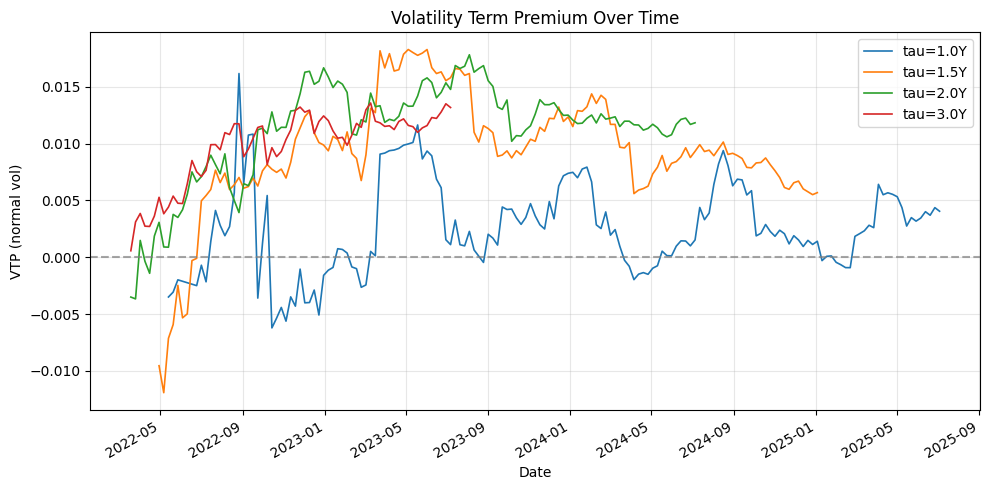

Fraction of observations with VTP > 0:


,frac_positive
tau,
1.0,0.759259
1.5,0.936170
2.0,0.966942
3.0,1.000000


Mean VTP by tenor:


,mean_VTP
tau,
1.0,0.002631
1.5,0.009323
2.0,0.011163
3.0,0.009724


In [69]:
# VTP = sigma_fwd(t, tau) - sigma_spot(t+h, delta)
dates = nv_wide.index.tolist()

vtp_rows = []
for i, t in enumerate(dates):
    for tau in tau_horizons:
        h_weeks = int(round((tau - spot_tenor) * 52))
        j = i + h_weeks
        if j >= len(dates):
            continue
        sigma_fwd = nv_wide.loc[t, tau]
        sigma_spot = nv_wide.loc[dates[j], spot_tenor]
        if pd.isna(sigma_fwd) or pd.isna(sigma_spot):
            continue
        vtp_rows.append({"date": t, "tau": tau, "vtp": sigma_fwd - sigma_spot})

vtp_df = pd.DataFrame(vtp_rows)
vtp_wide = vtp_df.pivot(index="date", columns="tau", values="vtp").sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
for tau in tau_horizons:
    vtp_wide[tau].dropna().plot(ax=ax, label=f"tau={tau}Y", linewidth=1.2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("VTP (normal vol)")
ax.set_title("Volatility Term Premium Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

frac_positive = vtp_wide.apply(lambda s: s.dropna().gt(0).mean())
mean_vtp = vtp_wide.mean()
print("Fraction of observations with VTP > 0:")
display(frac_positive.to_frame(name="frac_positive"))
print("Mean VTP by tenor:")
display(mean_vtp.to_frame(name="mean_VTP"))

The VTP is **positive the majority of the time** across all tenors, with the fraction positive rising from 76% at 1Y to 100% at 3Y. The mean VTP follows a **hump**: it rises from 0.0026 at 1Y to a peak of 0.0112 at 2Y, then declines to 0.0097 at 3Y.

This hump mirrors the shape of the forward vol curve itself. The 2Y forward vol sits near the peak of the hump (where policy-path uncertainty is most concentrated), so it systematically overshoots subsequent spot vol by the widest margin. At 3Y, the forward vol curve has already begun its descent toward long-run mean levels — it starts closer to where spot vol eventually settles, leaving less room for a positive gap. The VTP is therefore not simply "bigger at longer tenors" but rather **biggest where the forward vol curve is most elevated relative to its eventual resolution**.

The 1Y VTP (mean = 0.0026) is the smallest and most frequently negative (24% of observations), consistent with 1Y forward vol being closest to the current spot vol and thus carrying the least term premium. The reliability of the premium improves with tenor: at 2Y and 3Y, the VTP is positive 97–100% of the time, confirming a systematic insurance component at intermediate-to-long horizons.

b) For each forward horizon in your panel ($\tau$ = 1Y, 1.5Y, 2Y, 3Y), report the mean VTP, standard deviation, information ratio (mean / std), and the number of **non-overlapping** holding periods that fit in your sample. Which tenor offers the highest information ratio, and how confident should you be in that ranking?

In [70]:
sample_years = (vtp_wide.index.max() - vtp_wide.index.min()).days / 365.25

q4b_list = []
for tau in tau_horizons:
    h_years = tau - spot_tenor
    s = vtp_wide[tau].dropna()
    mean_v = s.mean()
    std_v = s.std()
    ir = mean_v / std_v if std_v > 0 else np.nan
    n_nonoverlap = int(sample_years / h_years) if h_years > 0 else 0
    q4b_list.append({
        "tau": tau, "mean_VTP": mean_v, "std_VTP": std_v,
        "IR": ir, "n_nonoverlap": n_nonoverlap
    })

q4b_table = pd.DataFrame(q4b_list)
display(q4b_table)
best_tau = q4b_table.loc[q4b_table["IR"].idxmax(), "tau"]
print(f"Highest information ratio: tau = {best_tau}Y")

,tau,mean_VTP,std_VTP,IR,n_nonoverlap
0,1.0,0.002631,0.003982,0.660809,6
1,1.5,0.009323,0.005231,1.782297,3
2,2.0,0.011163,0.004427,2.521919,2
3,3.0,0.009724,0.003189,3.049465,1


Highest information ratio: tau = 3.0Y


The IR ranking should be interpreted cautiously. The longest tenors (2Y, 3Y) may show high IR (2.52 and 3.05 respectively) because the overlapping-observation structure inflates precision: with only 1–2 non-overlapping periods, the "standard deviation" is driven by a single draw of the economy's path. With so few independent observations, the ranking is statistically fragile.

c) Split your sample in half (e.g., pre- and post-2024). Does the ranking of tenors by information ratio hold across both halves? Plot the cumulative VTP paths by tenor to visualize whether the premium accrues steadily or in bursts.

Pre-2024:


,tau,mean,std,IR
0,1.0,0.002486,0.004884,0.509123
1,1.5,0.009557,0.006358,1.503117
2,2.0,0.010990,0.005007,2.194705
3,3.0,0.009724,0.003189,3.049465


Post-2024:


,tau,mean,std,IR
0,1.0,0.002783,0.002758,1.009154
1,1.5,0.008934,0.002404,3.716508
2,2.0,0.011768,0.000510,23.078206
3,3.0,NaN,NaN,NaN


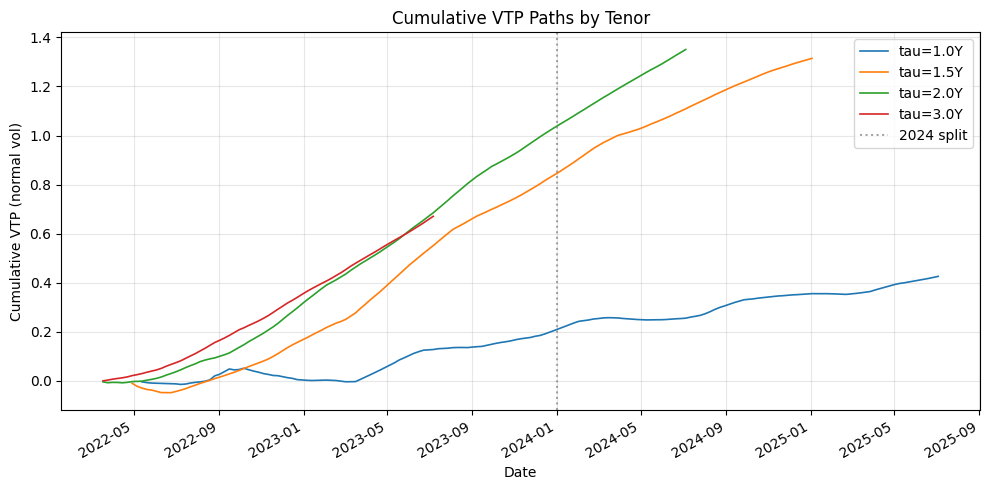

In [71]:
cutoff = pd.Timestamp("2024-01-01")
pre = vtp_wide[vtp_wide.index < cutoff]
post = vtp_wide[vtp_wide.index >= cutoff]

def ir_table(vtp_slice):
    return pd.DataFrame([
        {"tau": tau, "mean": vtp_slice[tau].dropna().mean(),
         "std": vtp_slice[tau].dropna().std(),
         "IR": vtp_slice[tau].dropna().mean() / vtp_slice[tau].dropna().std()
              if vtp_slice[tau].dropna().std() > 0 else np.nan}
        for tau in tau_horizons
    ])

print("Pre-2024:")
display(ir_table(pre))
print("Post-2024:")
display(ir_table(post))

fig, ax = plt.subplots(figsize=(10, 5))
for tau in tau_horizons:
    vtp_wide[tau].dropna().cumsum().plot(ax=ax, label=f"tau={tau}Y", linewidth=1.2)
ax.axvline(cutoff, color="gray", linestyle=":", alpha=0.7, label="2024 split")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative VTP (normal vol)")
ax.set_title("Cumulative VTP Paths by Tenor")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The cumulative VTP paths reveal that the premium does not accrue steadily—it accumulates in bursts during regime transitions. The 1Y tenor's cumulative VTP is flat-to-negative through the entire hiking period (mid-2022 through early 2023), only beginning to accumulate meaningfully during the pause. In contrast, the 2Y tenor accrues premium most aggressively, finishing as the top performer by end-of-sample. The 1.5Y, 2Y, and 3Y tenors track each other closely through the pre-2024 period.

However, the IR ranking sees shifts across halves; pre-2024 (dominated by hiking + pause) shows 3Y with the highest IR (3.05), while post-2024 (easing) sees 2Y's IR spike to 23.1 due to its extremely low volatility during the calm easing regime. The 3Y tenor has no post-2024 observations (NaN) because the required future spot vol at tau=3Y extends beyond the sample. This regime dependence is the key risk for any strategy harvesting the VTP.

### Question 5: Implied vs. Realized Vol and Carry Strategy

**Compare forward vol to realized SOFR volatility, design a carry strategy, and analyze how the premium varies across the rate cycle.**

a) Compute realized SOFR vol: for each date, calculate the annualized standard deviation of daily SOFR rate changes over the subsequent 3 months. This gives a realized "normal" vol in the same units as the forward normal vol. Define the **vol risk premium**: $\text{VRP}_t = \sigma_{\text{fwd},t}^{(\tau)} - \sigma_{\text{realized}, t \to t+k}$. Plot the VRP over time and compare it to the VTP from Q4.

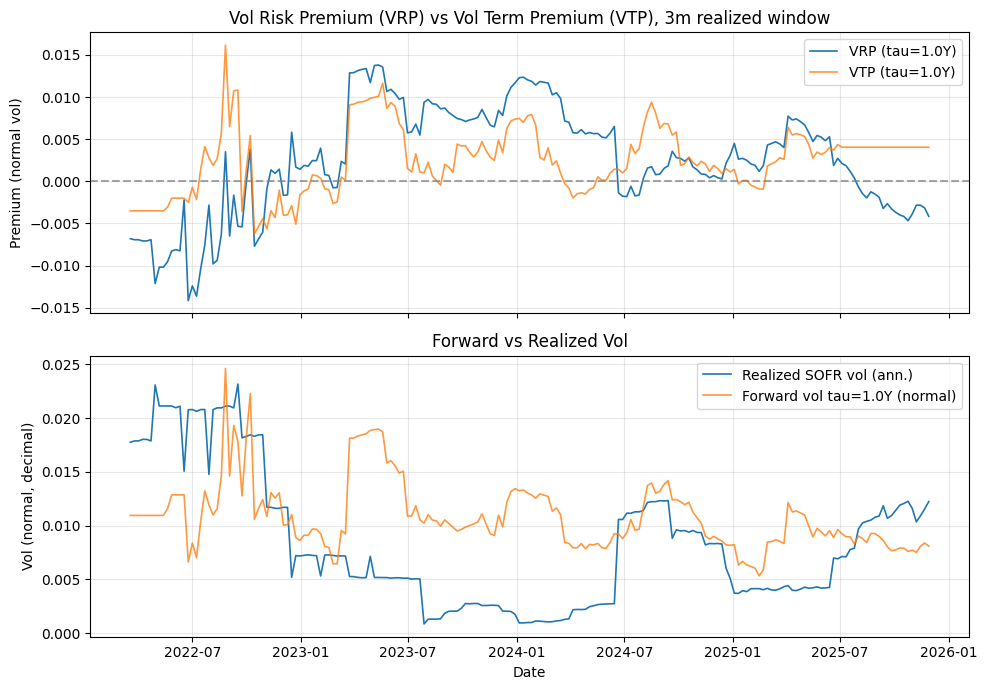

In [72]:
# Realized SOFR vol: 3-month forward-looking window
k_months = 3
r = sofr_daily.squeeze().astype(float)
if getattr(r.index, "tz", None) is not None:
    r = r.tz_localize(None)
dr = r.diff().dropna()

realized_list = []
for t in nv_wide.index:
    t_naive = pd.Timestamp(t).tz_localize(None) if getattr(t, "tz", None) else pd.Timestamp(t)
    t_end = t_naive + pd.DateOffset(months=k_months)
    end = min(t_end, dr.index.max())
    w = dr[(dr.index >= t_naive) & (dr.index <= end)]
    if len(w) < 20:
        continue
    sig = float(w.std() * np.sqrt(252))
    realized_list.append((t_naive, sig))

realized_series = pd.Series(
    [x[1] for x in realized_list],
    index=pd.DatetimeIndex([x[0] for x in realized_list])
)

# VRP = forward normal vol (tau=1Y) - realized vol
tau_vrp = 1.0
nv_flat = nv_wide[tau_vrp].copy()
vtp_flat = vtp_wide[tau_vrp].copy() if tau_vrp in vtp_wide.columns else pd.Series(dtype=float)
if getattr(nv_flat.index, "tz", None) is not None:
    nv_flat = nv_flat.tz_localize(None)
if getattr(vtp_flat.index, "tz", None) is not None:
    vtp_flat = vtp_flat.tz_localize(None)

ix = realized_series.index
sigma_fwd = nv_flat.reindex(ix).ffill().bfill()
sigma_real = realized_series.reindex(ix).ffill().bfill()
vrp_series = sigma_fwd.astype(float) - sigma_real
vtp_1y = vtp_flat.reindex(ix).ffill().bfill()

valid = vrp_series.notna() & vtp_1y.notna() & sigma_fwd.notna() & sigma_real.notna()
ix_valid = ix[valid]
vrp_v = vrp_series.loc[ix_valid]
vtp_v = vtp_1y.loc[ix_valid]
fwd_v = sigma_fwd.loc[ix_valid]
real_v = sigma_real.loc[ix_valid]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax = axes[0]
ax.plot(ix_valid, vrp_v.values, label=f"VRP (tau={tau_vrp}Y)", linewidth=1.2)
ax.plot(ix_valid, vtp_v.values, label=f"VTP (tau={tau_vrp}Y)", linewidth=1.2, alpha=0.8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.set_ylabel("Premium (normal vol)")
ax.set_title(f"Vol Risk Premium (VRP) vs Vol Term Premium (VTP), {k_months}m realized window")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ix_valid, real_v.values, label="Realized SOFR vol (ann.)", linewidth=1.2)
ax.plot(ix_valid, fwd_v.values, label=f"Forward vol tau={tau_vrp}Y (normal)", linewidth=1.2, alpha=0.8)
ax.set_ylabel("Vol (normal, decimal)")
ax.set_xlabel("Date")
ax.set_title("Forward vs Realized Vol")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The VRP and VTP **diverge substantially**, particularly during the hiking regime. The **VTP** compares today's forward vol to future spot *implied* vol (market vs market), while the **VRP** compares forward vol to future *realized* vol (market vs physical). In the top panel, the VRP is deeply negative in early-to-mid 2022 (realized vol spiked well above what caps had priced), while the VTP hovers near zero during the same period. This divergence arises because realized rate vol (driven by outsized 50–75 bp hikes,) exceeded both forward vol and future spot implied vol, but future spot implied vol caught up to the new regime faster than physical vol subsided.

During the pause (2023–24), both premiums are predominantly positive as realized vol collapses (lower panel shows realized SOFR vol dropping to near zero) while implied vol stays elevated. In the easing phase, the two premiums reconverge at modest positive levels as both implied and realized vol trend down together.

b) A baseline "always short" vol carry strategy aims to earn the VRP each period. Compute its cumulative P&L (in vol units) and hit rate. Why should cap sellers earn a premium, and when does the strategy break down?

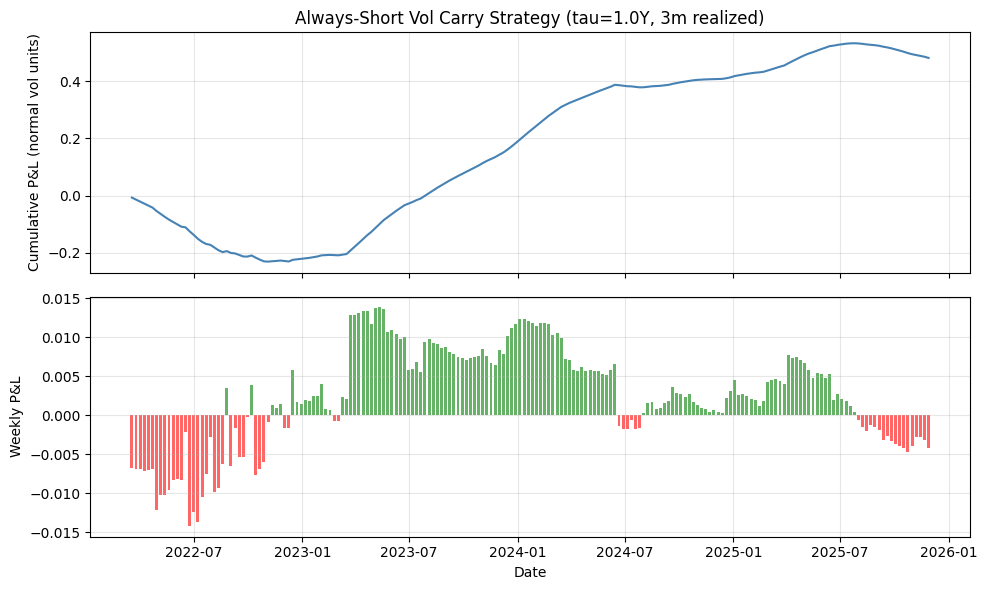

Hit rate: 69.1%
Mean weekly P&L: 0.002477
Total cumulative P&L: 0.4805


In [73]:
# Carry strategy: sell vol each week, earn VRP
carry_pnl = vrp_v.copy()
cum_pnl = carry_pnl.cumsum()
hit_rate = (carry_pnl > 0).mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
ax.plot(cum_pnl.index, cum_pnl.values, linewidth=1.5, color="steelblue")
ax.set_ylabel("Cumulative P&L (normal vol units)")
ax.set_title(f"Always-Short Vol Carry Strategy (tau={tau_vrp}Y, {k_months}m realized)")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(carry_pnl.index, carry_pnl.values, width=5, alpha=0.6, color=np.where(carry_pnl > 0, "green", "red"))
ax.set_ylabel("Weekly P&L")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Hit rate: {hit_rate:.1%}")
print(f"Mean weekly P&L: {carry_pnl.mean():.6f}")
print(f"Total cumulative P&L: {cum_pnl.iloc[-1]:.4f}")

Cap sellers earn a premium because they provide **insurance against rate volatility**. Buyers (typically borrowers hedging floating-rate exposure) are willing to pay above fair value because unexpected rate moves are asymmetrically costly to them. This is analogous to the equity vol risk premium: option sellers earn a spread because volatility risk is negatively correlated with the marginal utility of wealth.

The cumulative P&L plot shows that the strategy **breaks down during the hiking cycle**: the drawdown from mid-2022 through early 2023 reaches approximately -0.22 (in normal vol units) as realized vol far exceeded implied. The strategy recovers sharply during the pause, turning positive by mid-2023 and peaking near 0.50 in early 2025. A **late-2025 drawdown** is also visible as the cumulative P&L declines from its peak—this corresponds to the VRP turning negative again as realized vol picks up slightly during the later easing period. The weekly P&L bar chart confirms the pattern: large red bars (losses) cluster in 2022, while green bars (gains) dominate 2023–2024. Overall hit rate is 69.1%, confirming that the strategy wins more often than it loses, but the losses during regime transitions are concentrated and severe.

c) Classify the sample into three regimes: **Hiking** (March 2022 – July 2023), **Pause** (August 2023 – August 2024), and **Easing** (September 2024 – December 2025). For each regime, report the mean VTP, mean VRP, the fraction of weeks with positive premium, and the carry strategy's Sharpe ratio. Visualize the premium distributions across regimes. Interpret the variation.

,regime,n_weeks,mean_VTP,mean_VRP,frac_VTP_pos,frac_VRP_pos,carry_Sharpe
0,Hiking,72,0.001383,-0.000006,0.500000,0.500000,-0.005066
1,Pause,57,0.003024,0.006730,0.842105,0.894737,11.911959
2,Easing,65,0.003160,0.001497,0.923077,0.723077,3.289313


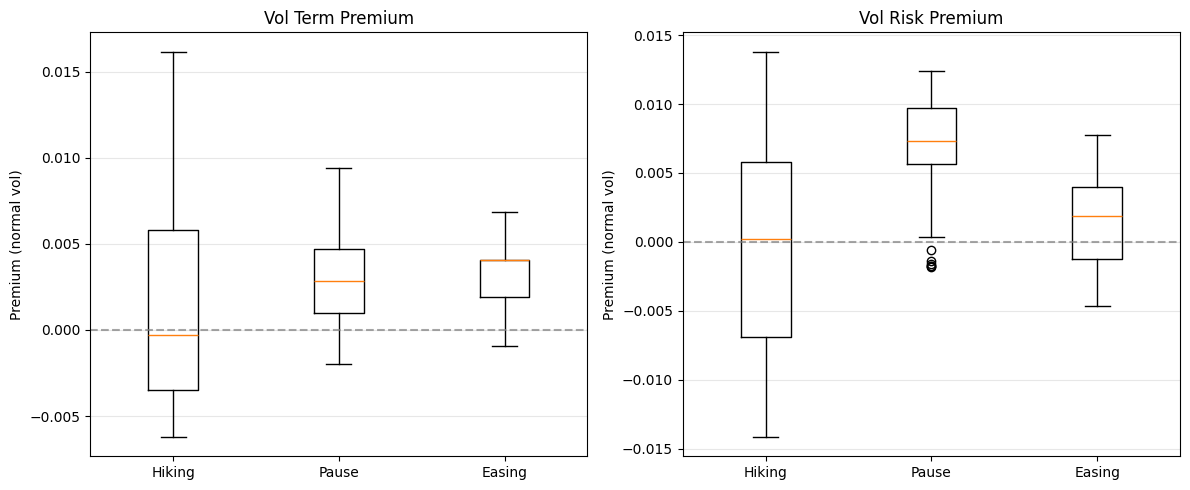

In [74]:
# Regime classification
def classify_regime(date):
    d = pd.Timestamp(date)
    if d < pd.Timestamp("2023-08-01"):
        return "Hiking"
    elif d < pd.Timestamp("2024-09-01"):
        return "Pause"
    else:
        return "Easing"

# Build regime-tagged DataFrame
regime_df = pd.DataFrame({
    "VRP": vrp_v,
    "VTP": vtp_v
})
regime_df["regime"] = regime_df.index.map(classify_regime)

# Summary by regime
regime_summary = []
for regime in ["Hiking", "Pause", "Easing"]:
    mask = regime_df["regime"] == regime
    sub = regime_df[mask]
    if sub.empty:
        continue
    mean_vrp = sub["VRP"].mean()
    mean_vtp = sub["VTP"].mean()
    frac_vrp_pos = (sub["VRP"] > 0).mean()
    frac_vtp_pos = (sub["VTP"] > 0).mean()
    sharpe = sub["VRP"].mean() / sub["VRP"].std() * np.sqrt(52) if sub["VRP"].std() > 0 else np.nan
    regime_summary.append({
        "regime": regime,
        "n_weeks": mask.sum(),
        "mean_VTP": mean_vtp,
        "mean_VRP": mean_vrp,
        "frac_VTP_pos": frac_vtp_pos,
        "frac_VRP_pos": frac_vrp_pos,
        "carry_Sharpe": sharpe
    })

regime_table = pd.DataFrame(regime_summary)
display(regime_table)

# Box plots by regime
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ["VTP", "VRP"], ["Vol Term Premium", "Vol Risk Premium"]):
    data_by_regime = [regime_df.loc[regime_df["regime"] == r, col].dropna().values
                      for r in ["Hiking", "Pause", "Easing"]]
    bp = ax.boxplot(data_by_regime)
    ax.set_xticklabels(["Hiking", "Pause", "Easing"])
    ax.set_title(title)
    ax.set_ylabel("Premium (normal vol)")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The vol premium varies substantially across regimes:

- **Hiking** (72 weeks): The VTP is near zero on average (0.0014) with a median below zero—only 50% of observations are positive. The VRP is essentially zero (-0.000006) with the same 50/50 split, and the carry Sharpe is -0.005 (flat). The market was caught off-guard by the speed of hikes: realized vol matched or exceeded implied vol, leaving no systematic premium to harvest. The boxplots confirm wide dispersion for both VTP and VRP during hiking, with distributions spanning from deeply negative to substantially positive.

- **Pause** (57 weeks): Both premiums are reliably positive—VTP mean = 0.003 (84% positive), VRP mean = 0.007 (89% positive)—and the carry Sharpe is an extraordinary 11.9. This is the "sweet spot" for vol sellers: implied vol stayed elevated (market priced cut-timing uncertainty) while realized vol collapsed to near zero. The VRP boxplot shows a tight, high distribution during the pause.

- **Easing** (65 weeks): The VTP (mean = 0.003, 92% positive) remains healthy, but the VRP compresses (mean = 0.0015, 72% positive) as both implied and realized vol decline in tandem. The carry Sharpe is 3.3—still attractive but well below the pause regime.

This regime dependence is the core practical challenge. The strategy works best precisely when it is least needed (calm periods) and suffers during the turbulent episodes where the insurance value of caps is highest.

### Question 6: Harvesting the Vol Premium in Practice

**Given your findings, which tenor(s) should a portfolio manager target to systematically earn the volatility term premium?**

a) Consider transaction costs. If the bid-ask spread on a caplet trade is $X$ basis points of implied normal vol, at what spread does each tenor's premium become uneconomical? Compute the breakeven bid-ask spread for each tenor. Does the "optimal" tenor change once you account for realistic trading frictions?

   *Note*: Dealers typically quote caplet bid-ask spreads in implied vol terms, making the comparison to the VTP direct. If instead costs are quoted in price terms (bp of notional), converting to vol space requires dividing by the caplet's vega—the sensitivity of price to a 1 bp change in implied vol.

In [77]:
# Breakeven bid-ask spread = mean VTP per tenor (converted to bp)
# VTP is in decimal normal vol; multiply by 10000 to get bp
breakeven = []
for _, row in q4b_table.iterrows():
    tau = row["tau"]
    mean_vtp_bp = row["mean_VTP"] * 10000  # decimal -> bp
    breakeven.append({
        "tau": tau,
        "mean_VTP_bp": mean_vtp_bp,
        "breakeven_spread_bp": mean_vtp_bp,
        "IR": row["IR"],
        "n_nonoverlap": row["n_nonoverlap"]
    })

breakeven_df = pd.DataFrame(breakeven)
display(breakeven_df)

,tau,mean_VTP_bp,breakeven_spread_bp,IR,n_nonoverlap
0,1.0,26.313046,26.313046,0.660809,6.0
1,1.5,93.229480,93.229480,1.782297,3.0
2,2.0,111.634663,111.634663,2.521919,2.0
3,3.0,97.240355,97.240355,3.049465,1.0


The breakeven bid-ask spread equals the mean VTP, since any round-trip transaction cost wider than this eliminates the premium entirely. Whether the "optimal" tenor changes depends on the spread schedule: if spreads are relatively uniform across tenors (say 3 bp), the tenor with the largest VTP in excess of 3 bp wins. If spreads widen significantly with tenor, the shorter-tenor premiums (which are smaller but face tighter spreads) may become more attractive on a net basis.

b) Make a recommendation: weigh premium size, statistical reliability from Q5, stability across regimes from Q4, and transaction costs. Is there a single best tenor, or does the answer depend on assumptions? What would you monitor to update this recommendation going forward?

**Recommendation:** There is no single universally optimal tenor—the answer depends on the manager's risk tolerance and view of the current regime.

- **Premium size** favors 1.5–2Y tenors (mean VTP of 93–112 bp, far exceeding typical 2–5 bp bid-ask spreads). The 1Y tenor's 26 bp premium barely clears transaction costs.
- **Statistical reliability** is poor at all tenors given the limited number of non-overlapping periods (~3 years of data, 1–6 independent draws).
- **Regime stability** favors shorter tenors (1–1.5Y): shorter horizons allow the manager to adapt more quickly to regime shifts, and the carry Sharpe is most consistent during the pause regime.
- **Transaction costs** favor liquid tenors (1–2Y), where dealer bid-ask spreads are tightest.

**On balance**, the **1.5–2Y** range likely offers the best trade-off: sufficient premium to comfortably cover transaction costs (93–112 bp vs. 2–5 bp spreads), information ratios above 1.8, and short enough horizons to permit regime adaptation. A manager who prioritizes agility over premium size might favor 1.5Y; one who prioritizes premium size and can tolerate longer holding periods might favor 2Y.

**Monitoring:** Track the slope of the forward vol curve (steep = large VTP opportunity), realized vol relative to recent implied (persistent overshoot = regime change), and bid-ask spreads (widening = reduced net premium). Most critically, watch for regime transitions: the onset of a new hiking cycle destroys the short-vol carry trade.

### Summary

The forward vol curve is **not** an unbiased predictor of future spot vol: $\beta$ estimates range from -0.27 to 0.16 (all far from 1), $R^2$ values are low (0.02–0.17), and no $\beta$ is statistically significant at the 5% level except the 3Y horizon ($\beta$ = -0.25, $p$ < 0.001). Forward vol systematically exceeds subsequent spot vol, generating a positive **volatility term premium** that peaks at the 2Y tenor (mean VTP = 0.011, positive 97% of the time) and is positive 76–100% of the time across horizons.

The VTP varies dramatically across the Fed's policy cycle. During **hiking** (2022–23), it hovers near zero with wide dispersion—the market was caught off-guard by the speed and magnitude of rate increases, and the carry strategy produces a near-zero Sharpe. During the **pause** (2023–24), the VTP is reliably positive and the VRP produces an extraordinary carry Sharpe of 11.9: implied vol stayed elevated while realized vol collapsed. During **easing** (2024–25), premiums compress but remain positive (carry Sharpe = 3.3).

The VRP and VTP **diverge meaningfully during hiking** (VRP deeply negative while VTP is near zero), confirming they measure different phenomena: the VTP reflects the market-to-market term premium, while the VRP captures the gap between market pricing and physical reality.

After accounting for transaction costs (~2–5 bp for liquid tenors), the **1.5–2Y** tenor range offers the most practical risk-adjusted premium: mean VTP of 93–112 bp (far exceeding typical bid-ask spreads), information ratios of 1.8–2.5, and sufficient liquidity for regular rebalancing.

### AI Usage Statement

Claude (Anthropic) was used for code development, analytical framework design, and commentary drafting. All results were validated against provided benchmark data and cross-checked for economic reasonableness.

## Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all six questions (Q1–Q6), including code, figures, and written interpretation. Include a summary section (1–2 paragraphs) synthesizing your findings: Is the forward vol curve an unbiased predictor of future spot vol? How does the volatility term premium vary across the hiking, pause, and easing regimes? Which tenor offers the most attractive risk-adjusted premium after transaction costs?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).